# Soft-DTW Ball Visualization

This notebook visualizes the level sets of Soft-DTW distance between:
- A fixed center time series $x$ of length $k=5$
- A variable query time series $y$ of length $m=2$

We map the 2-element query series to a 2D plane where x-axis = $y_1$ and y-axis = $y_2$.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Soft-Minimum Function

The soft-minimum operator with log-sum-exp stabilization:

$$\min^\gamma \{a_1, \dots, a_n\} := -\gamma \log \sum_{i=1}^n e^{-a_i/\gamma}$$

Using the stabilization trick: $\log \sum_i e^{z_i} = (\max_j z_j) + \log \sum_i e^{z_i - \max_j z_j}$

In [12]:
def softmin(values, gamma):
    """
    Compute the soft-minimum of a list/array of values using log-sum-exp stabilization.
    
    Parameters:
    -----------
    values : array-like
        The values to compute the soft-minimum over
    gamma : float
        The smoothing parameter (gamma > 0)
    
    Returns:
    --------
    float
        The soft-minimum value
    """
    values = np.array(values)
    
    # Compute -values/gamma for the exponential
    z = -values / gamma
    
    # Use log-sum-exp trick: max_z + log(sum(exp(z - max_z)))
    max_z = np.max(z)
    log_sum_exp = max_z + np.log(np.sum(np.exp(z - max_z)))
    
    # Return -gamma * log_sum_exp
    return -gamma * log_sum_exp

## 2. Soft-DTW Forward Pass

The dynamic programming algorithm:

**Distance function:** $\delta(x_i, y_j) = (x_i - y_j)^2$

**Initialization:**
- $r_{0,0} = 0$
- $r_{i,0} = \infty$ for $i \in \{1, \dots, n\}$
- $r_{0,j} = \infty$ for $j \in \{1, \dots, m\}$

**Recurrence relation:**
$$r_{i,j} = \delta(x_i, y_j) + \min^\gamma \{ r_{i-1,j-1}, r_{i-1,j}, r_{i,j-1} \}$$

In [13]:
def soft_dtw(x, y, gamma):
    """
    Compute the Soft-DTW distance between two time series.
    
    Parameters:
    -----------
    x : array-like
        First time series of length n
    y : array-like
        Second time series of length m
    gamma : float
        Smoothing parameter (gamma > 0)
    
    Returns:
    --------
    float
        The Soft-DTW distance
    """
    x = np.array(x)
    y = np.array(y)
    
    n = len(x)
    m = len(y)
    
    # Initialize DP table with shape (n+1) x (m+1)
    R = np.full((n + 1, m + 1), np.inf)
    R[0, 0] = 0.0
    
    # Fill the DP table
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Compute squared Euclidean distance
            delta = (x[i - 1] - y[j - 1]) ** 2
            
            # Compute soft-minimum of three predecessors
            r_min = softmin([R[i - 1, j - 1], R[i - 1, j], R[i, j - 1]], gamma)
            
            # Update DP table
            R[i, j] = delta + r_min
    
    # Return the final Soft-DTW distance
    return R[n, m]

## 3. Visualization Setup

We'll visualize the level sets of Soft-DTW distance from a fixed center series to all possible 2-element query series $(y_1, y_2)$.

In [14]:
# Define the fixed center time series of length k=5
x_center = np.array([-1.5, 0, 0.6, 2, -1])

# Create a meshgrid for y1 and y2
resolution = 50
y1_range = np.linspace(-3, 3, resolution)
y2_range = np.linspace(-3, 3, resolution)
Y1, Y2 = np.meshgrid(y1_range, y2_range)

print(f"Center series x: {x_center}")
print(f"Meshgrid resolution: {resolution}x{resolution}")
print(f"Range: y1, y2 ∈ [{y1_range.min()}, {y1_range.max()}]")

Center series x: [-1.5  0.   0.6  2.  -1. ]
Meshgrid resolution: 50x50
Range: y1, y2 ∈ [-3.0, 3.0]


## 4. Compute Soft-DTW Distances

For each gamma value, compute the Soft-DTW distance at every point in the meshgrid.

In [15]:
# Define gamma values to compare
gamma_values = [0.001, 0.01, 1.0, 10.0, 50.0, 500.0]

# Dictionary to store distance matrices
distance_matrices = {}

# Compute Soft-DTW distance for each gamma
for gamma in gamma_values:
    print(f"Computing distances for gamma = {gamma}...")
    distances = np.zeros_like(Y1)
    
    for i in range(resolution):
        for j in range(resolution):
            y_query = np.array([Y1[i, j], Y2[i, j]])
            distances[i, j] = soft_dtw(x_center, y_query, gamma)
    
    distance_matrices[gamma] = distances
    print(f"  Min distance: {distances.min():.4f}, Max distance: {distances.max():.4f}")

print("\nAll computations complete!")

Computing distances for gamma = 0.001...
  Min distance: 4.7242, Max distance: 53.2086
Computing distances for gamma = 0.01...
  Min distance: 4.7242, Max distance: 53.1961
Computing distances for gamma = 1.0...
  Min distance: 4.3309, Max distance: 51.7932
Computing distances for gamma = 10.0...
  Min distance: -14.0071, Max distance: 35.6854
Computing distances for gamma = 50.0...
  Min distance: -101.7500, Max distance: -44.8653
Computing distances for gamma = 500.0...
  Min distance: -1090.4726, Max distance: -1032.2924

All computations complete!


## 5. Plot the Level Sets

Create side-by-side contour plots showing how the Soft-DTW "balls" change with different gamma values.

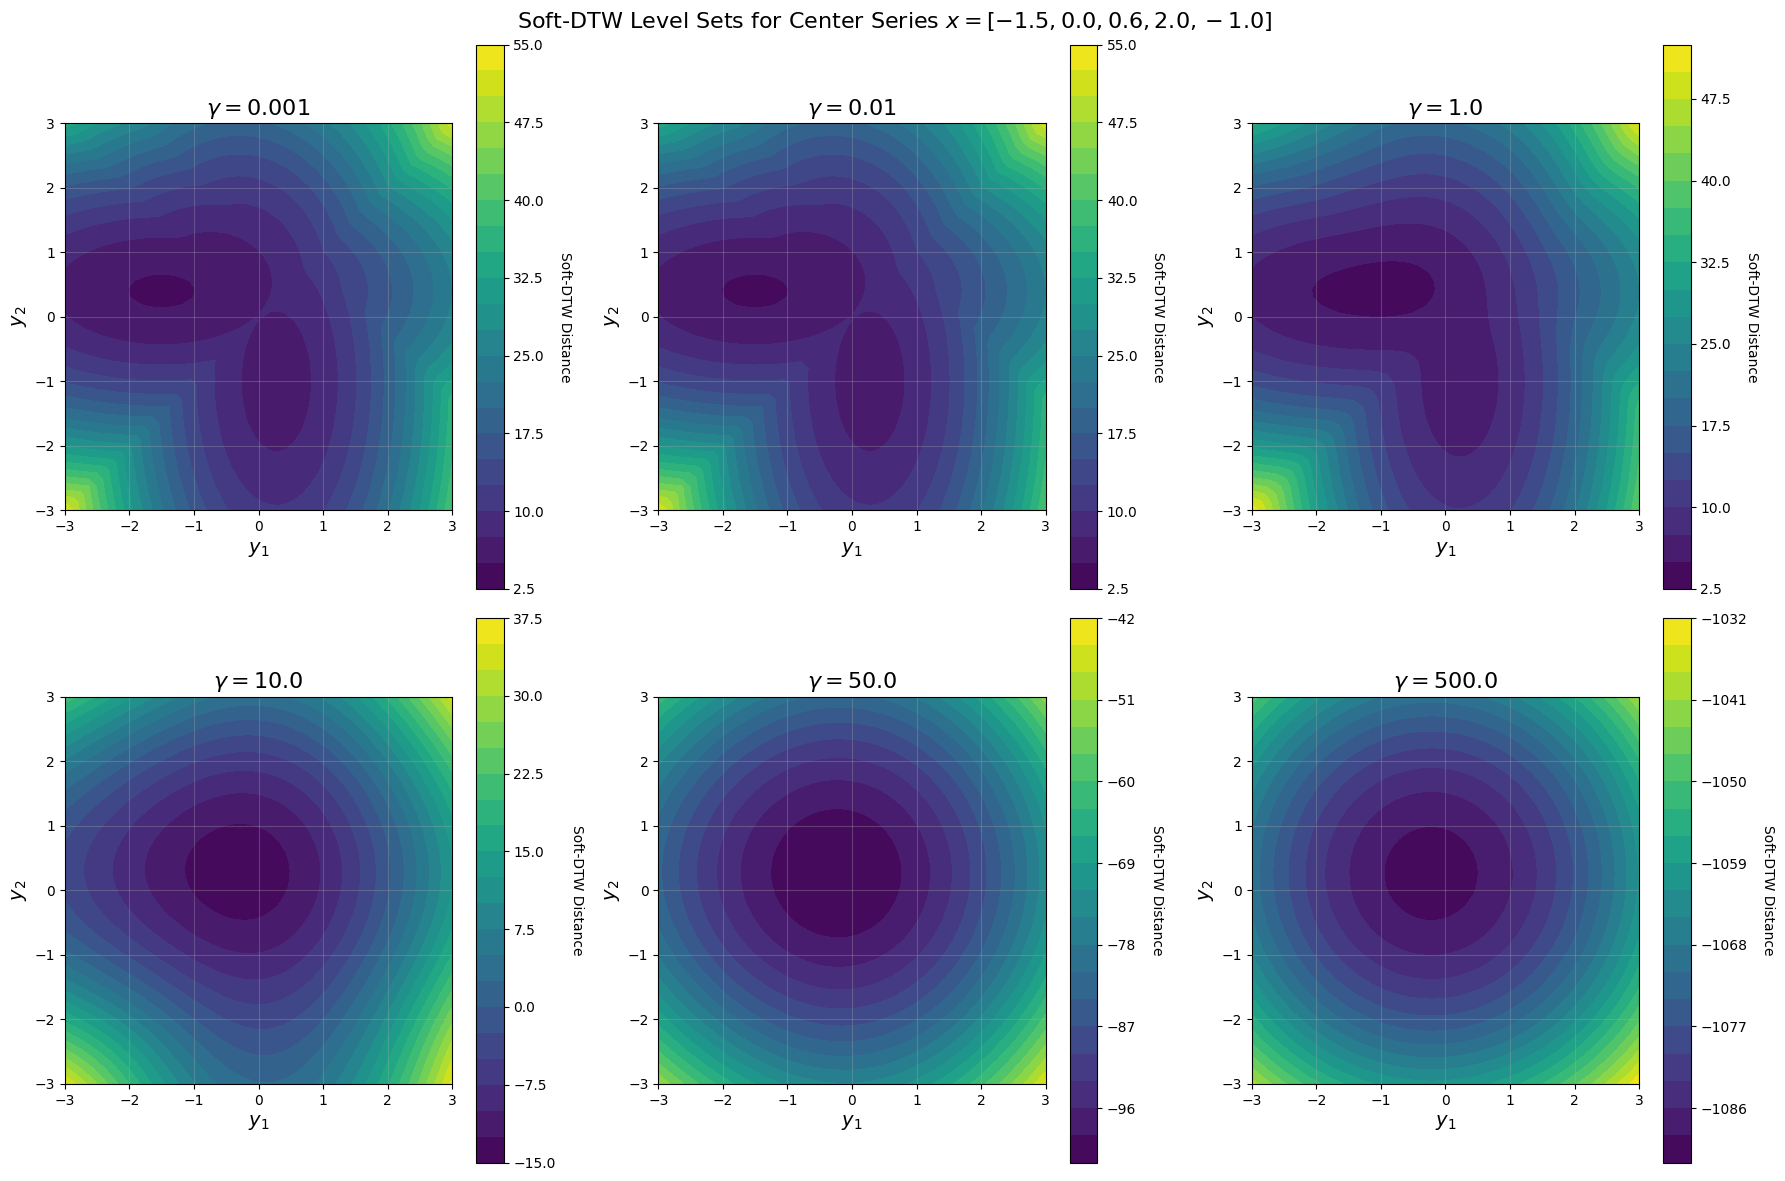

In [16]:
# Create a figure with subplots in a grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # Flatten to easily iterate

for idx, gamma in enumerate(gamma_values):
    ax = axes[idx]
    distances = distance_matrices[gamma]
    
    # Create contour plot
    contour = ax.contourf(Y1, Y2, distances, levels=20, cmap='viridis')
    
    # Add colorbar
    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_label('Soft-DTW Distance', rotation=270, labelpad=20)
    
    # Labels and title
    ax.set_xlabel('$y_1$', fontsize=14)
    ax.set_ylabel('$y_2$', fontsize=14)
    ax.set_title(f'$\\gamma = {gamma}$', fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
# Hide the unused subplot
if len(gamma_values) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle(f'Soft-DTW Level Sets for Center Series $x = {list(x_center)}$', 
             fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## 6. Plot Soft-DTW Ball Boundaries

Visualize the boundary of a Soft-DTW ball at a specific distance threshold for different gamma values.

/var/folders/qc/gl6rlk253fs0zbvjtf9kjsmw0000gn/T/ipykernel_69790/871363257.py:67: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_line.collections[0].get_paths()


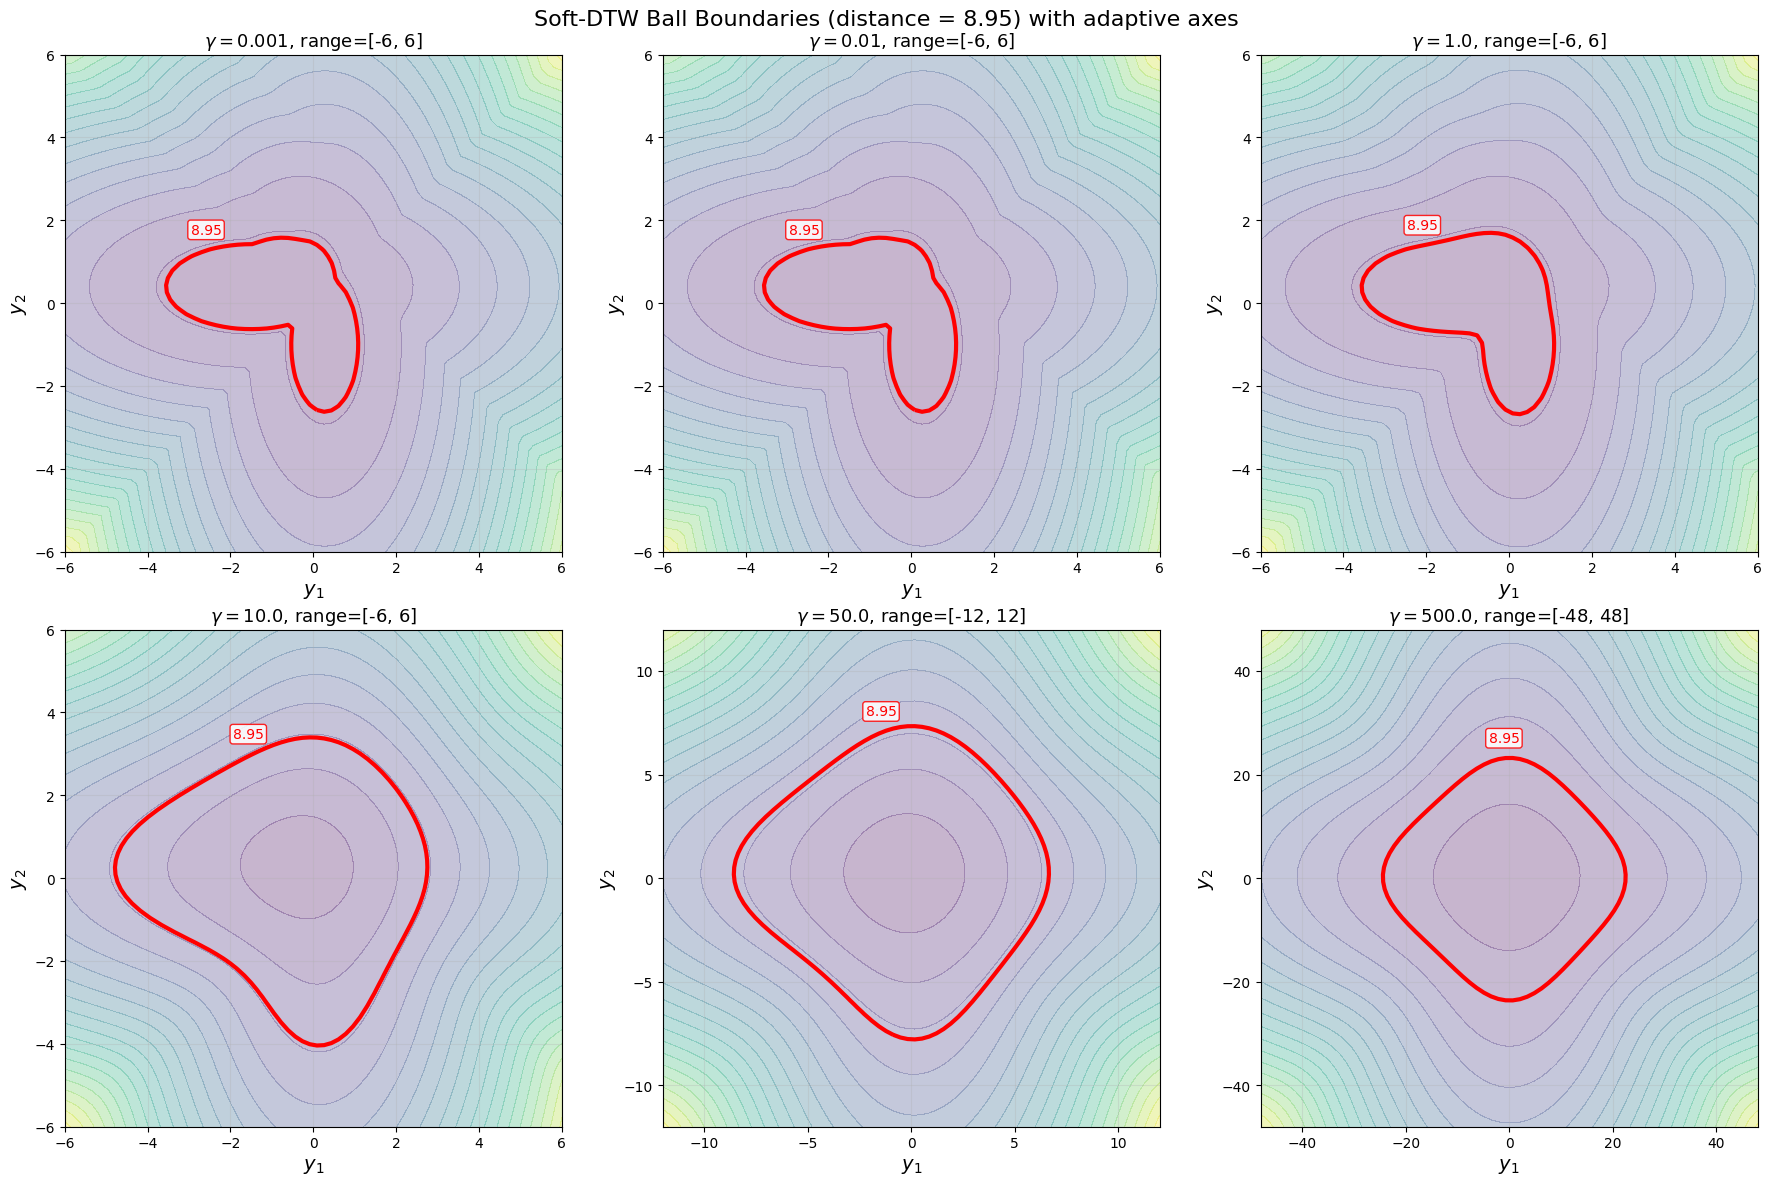

Ball boundary shown at Soft-DTW distance = 8.9457
Axes are adapted per gamma to keep boundaries inside frame when possible.


In [19]:
# Choose a distance threshold for the ball boundary
# Use a percentile to get a reasonable threshold
distance_threshold = np.percentile(distance_matrices[1.0], 30)


def compute_distance_grid_for_gamma(gamma, limit, resolution=60):
    """Compute Soft-DTW distances on a square grid [-limit, limit]^2 for one gamma."""
    y1 = np.linspace(-limit, limit, resolution)
    y2 = np.linspace(-limit, limit, resolution)
    G1, G2 = np.meshgrid(y1, y2)

    D = np.zeros_like(G1)
    for i in range(resolution):
        for j in range(resolution):
            y_query = np.array([G1[i, j], G2[i, j]])
            D[i, j] = soft_dtw(x_center, y_query, gamma)

    return G1, G2, D


def contour_touches_border(D, level):
    """
    Heuristic check if contour at `level` likely intersects the grid border.
    If border values straddle the level, the contour can hit/cross the frame.
    """
    boundary_vals = np.concatenate([
        D[0, :],
        D[-1, :],
        D[:, 0],
        D[:, -1],
    ])
    return boundary_vals.min() <= level <= boundary_vals.max()


def find_adaptive_limit(gamma, threshold, initial_limit=3.0, max_limit=96.0, resolution=70):
    """
    Expand plotting range until:
      1) threshold is inside [min(D), max(D)] so contour exists, and
      2) contour no longer appears to touch border (to avoid clipping).
    """
    limit = initial_limit
    G1 = G2 = D = None

    while True:
        G1, G2, D = compute_distance_grid_for_gamma(gamma, limit, resolution=resolution)
        dmin, dmax = D.min(), D.max()

        level_exists = (dmin <= threshold <= dmax)
        clipped = contour_touches_border(D, threshold) if level_exists else False

        if level_exists and (not clipped):
            return limit, G1, G2, D, True

        if limit >= max_limit:
            # Best effort: return latest grid; may still be clipped
            return limit, G1, G2, D, False

        limit *= 2.0


def add_label_next_to_contour(ax, contour_line, label_text, color='red'):
    """
    Place a label next to (not on) one contour segment.
    """
    try:
        # Pick the longest contour path for stable placement
        paths = contour_line.collections[0].get_paths()
        if len(paths) == 0:
            return

        path_lengths = [len(p.vertices) for p in paths]
        path = paths[int(np.argmax(path_lengths))]
        verts = path.vertices
        if len(verts) < 2:
            return

        mid_idx = len(verts) // 2
        x0, y0 = verts[mid_idx]

        # Local tangent and normal for offset direction
        i0 = max(0, mid_idx - 1)
        i1 = min(len(verts) - 1, mid_idx + 1)
        tx = verts[i1, 0] - verts[i0, 0]
        ty = verts[i1, 1] - verts[i0, 1]

        # Normal vector
        nx, ny = -ty, tx
        norm = np.hypot(nx, ny)
        if norm < 1e-12:
            nx, ny = 1.0, 0.0
            norm = 1.0
        nx /= norm
        ny /= norm

        # Offset relative to current axis span
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        span = max(xlim[1] - xlim[0], ylim[1] - ylim[0])
        offset = 0.04 * span

        xt = x0 + offset * nx
        yt = y0 + offset * ny

        ax.text(
            xt,
            yt,
            label_text,
            color=color,
            fontsize=10,
            ha='center',
            va='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor=color, boxstyle='round,pad=0.2')
        )
    except Exception:
        # Safe fallback: skip annotation if contour internals differ
        pass


# Create a figure with subplots in a grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # Flatten to easily iterate

for idx, gamma in enumerate(gamma_values):
    ax = axes[idx]

    # Adapt axes/range for each gamma to capture the boundary inside the frame
    limit, G1, G2, distances, fully_inside = find_adaptive_limit(
        gamma,
        distance_threshold,
        initial_limit=3.0,
        max_limit=96.0,
        resolution=70,
    )

    # Plot filled contours as background
    contourf = ax.contourf(G1, G2, distances, levels=20, cmap='viridis', alpha=0.3)

    # Plot the ball boundary at the threshold when possible
    if distances.min() <= distance_threshold <= distances.max():
        contour_line = ax.contour(
            G1,
            G2,
            distances,
            levels=[distance_threshold],
            colors='red',
            linewidths=3,
        )

        # Label next to boundary (instead of on the line)
        add_label_next_to_contour(ax, contour_line, f'{distance_threshold:.2f}', color='red')
    else:
        ax.text(
            0.5,
            0.5,
            'Boundary level not in range',
            transform=ax.transAxes,
            ha='center',
            va='center',
            color='red',
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'),
        )

    # Labels and title
    status = 'inside' if fully_inside else 'best effort'
    ax.set_xlabel('$y_1$', fontsize=14)
    ax.set_ylabel('$y_2$', fontsize=14)
    ax.set_title(f'$\\gamma = {gamma}$, range=[{-limit:.0f}, {limit:.0f}]', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

# Hide the unused subplot
if len(gamma_values) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle(
    f'Soft-DTW Ball Boundaries (distance = {distance_threshold:.2f}) with adaptive axes',
    fontsize=16,
    y=0.98,
)
plt.tight_layout()
plt.show()

print(f"Ball boundary shown at Soft-DTW distance = {distance_threshold:.4f}")
print("Axes are adapted per gamma to keep boundaries inside frame when possible.")